# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [2]:
import matplotlib.pyplot as plt #Imports
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from scipy import integrate

dEM=3.8e8 #Unrelated constants
exh_v=2.4e3
burn=1.3e4
Mwet=2.8e6
Mdry=7.5e5

Me=5.9e24 #Earth constants
Re=6378e3
G=6.67e-11 
g=9.81

Mm=7.3e22 #Moon constants
Rm=1737e3

Macm=5500 #Apollo command module constant
%pwd

'/Users/nicholasmanic/Documents/GitHub/PHYS265-spring26/Lab1'

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
def g_potent(M,x_m,y_m,x,y):
    """A function which calculates the gravitational potential of a body with mass M at a distance

    Args:
        M (int,float,or numpy array): the mass of the body in kilograms
        x_m (int,float,or numpy array): the x location of the body in meters
        y_m (int,float,or numpy array): the y location of the body in meters
        x (int,float,or numpy array): the x location of the evaluation point in meters
        y (int,float,or numpy array): the y location of the evaluation point in meters

    Returns:
        potent (int,float,or numpy array): the gravitational potential at the evaluation point in joules/kilogram
    
    """
    #Checks if all inputs are correct type
    if not all(isinstance(v,(int,float,np.ndarray)) for v in (M,x_m,y_m,x,y)):
        raise TypeError(f"Inputs are of the wrong type (int,float,or numpy array)")
    
    x_dif=abs(x_m-x)
    y_dif=abs(y_m-y)
    r=np.sqrt(x_dif**2+y_dif**2) #Distance between evaluation point and center of body M
    #Checks that the distance isn't 0 or else equation will fail by dividing by 0
    if np.any(r==0):
        raise ValueError(f"Distance between points cannot be 0")

    potent=-(G*M)/r #Evaluating potent from mass M at distance r 
    if not isinstance(potent, (int,float,np.ndarray)):
        raise TypeError(f"Output of the wrong type")
    
    return potent

2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

Text(0.5, 1.0, 'Gravitational potential (J/kg) as function of distance x (m)')

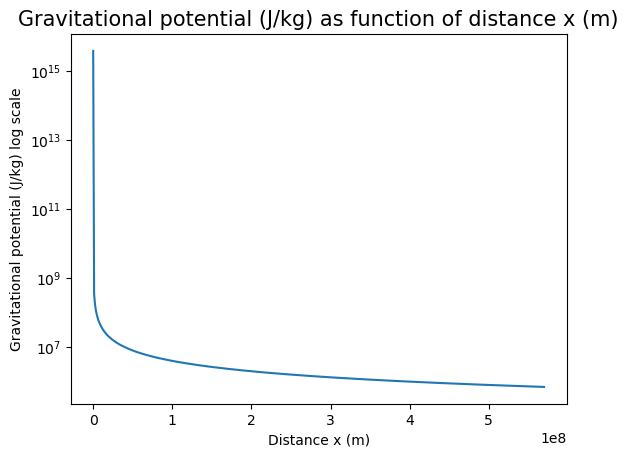

In [4]:
x=np.linspace(0.1, dEM*1.5,500)
potent=np.ones(500) #Placeholder values

#For loop that goes through all values in potent array using all values of distance array
for i in range(len(x)):
    potent[i]=g_potent(Me,0.0,0.0,x[i],0.0)

#Creating figure and axis
fig,ax=plt.subplots()
#Plotting x and y values
ax.plot(x,abs(potent))
#Setting log scale for better visualization
ax.set_yscale("log")

#Polishing graph
ax.set_xlabel("Distance x (m)")
ax.set_ylabel("Gravitational potential (J/kg) log scale")
plt.title("Gravitational potential (J/kg) as function of distance x (m)",fontsize=15)


3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

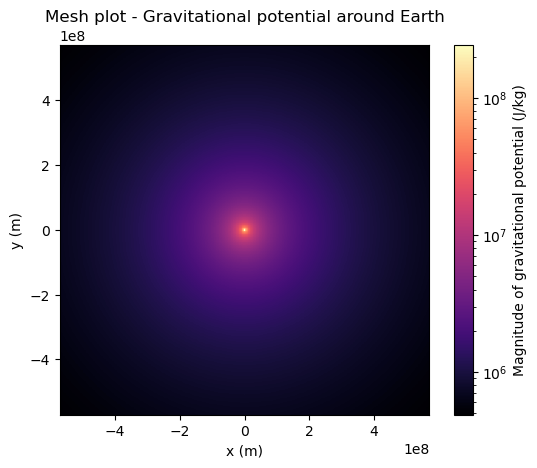

In [5]:
#Creating range of x and y values from -1.5dEM to 1.5 dEM
x=np.linspace(-1.5*dEM,1.5*dEM,500)
y=np.linspace(-1.5*dEM,1.5*dEM,500)
X,Y=np.meshgrid(x,y)
r = np.sqrt(X**2 + Y**2)

potent=g_potent(Me,0.0,0.0,X,Y)

fig, ax=plt.subplots()
ax.set_aspect("equal")
mesh=ax.pcolormesh(X,Y,-potent,cmap='magma',norm=LogNorm())
cbar=fig.colorbar(mesh)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
plt.title("Mesh plot - Gravitational potential around Earth")
cbar.set_label("Magnitude of gravitational potential (J/kg)")


## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

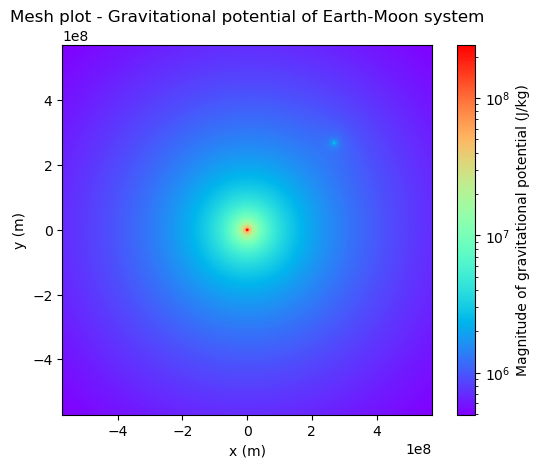

In [6]:
potent_e=g_potent(Me,0.0,0.0,X,Y)
potent_m=g_potent(Mm,(dEM/np.sqrt(2)),(dEM/np.sqrt(2)),X,Y)
potent_total=potent_e+potent_m #Gravitational potential is a scalar thus it obeys superposition so it can be added

fig, ax=plt.subplots()
ax.set_aspect("equal")
mesh=ax.pcolormesh(X,Y,-potent_total,cmap='rainbow',norm=LogNorm())
cbar=fig.colorbar(mesh)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
plt.title("Mesh plot - Gravitational potential of Earth-Moon system")
cbar.set_label("Magnitude of gravitational potential (J/kg)")

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

Text(0.5, 1.0, 'Contour plot - Gravitational potential of Earth-Moon system')

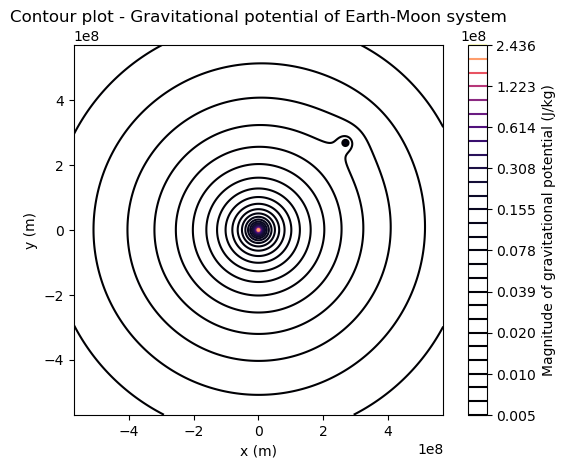

In [7]:
fig,ax=plt.subplots()
levels=np.logspace(
    np.log10(np.min(-potent_total)),
    np.log10(np.max(-potent_total)),
    28
)
cont=ax.contour(X,Y,-potent_total,cmap="magma",levels=levels)
ax.set_aspect("equal")
cbar=fig.colorbar(cont)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
cbar.set_label("Magnitude of gravitational potential (J/kg)")
ax.set_title("Contour plot - Gravitational potential of Earth-Moon system")

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
def g_force(m1,m2,x1,y1,x2,y2):
    """A function which calculates the gravitational force components experienced by a mass from another mass

    Args:
        m1 (int,float,or numpy array): the mass of body 1 in kilograms
        m2 (int,float,or numpy array): the mass of body 2 in kilograms
        x1 (int,float,or numpy array): the x location of body 1 in meters
        y1 (int,float,or numpy array): the y location of body 1 in meters
        x2 (int,float,or numpy array): the x location of body 2 in meters
        y2 (int,float,or numpy array): the y location of body 2 in meters

    Returns:
        Fx (int,float,or numpy array): The x component of the force in newtons
        Fy (int,float,or numpy array): The y component of the force in newtons 
    """
    #Checks if all inputs are correct type
    if not all(isinstance(v,(int,float,np.ndarray)) for v in (m1,m2,x1,y1,x2,y2)):
        raise TypeError(f"Inputs are of the wrong type (int,float,or numpy array)")

    #Solving for x and y difference between points to solve for total distance between bodies
    x_dif=x2-x1
    y_dif=y2-y1
    r=np.sqrt(x_dif**2+y_dif**2)

    vec_r=np.array([x_dif,y_dif]) # in the plane so r_z = 0
    vec_r_hat=vec_r/np.linalg.norm(vec_r) #calculating r's unit vector (r hat)

    #Checks that the distance isn't 0 or else equation will fail by dividing by 0
    if np.any(r==0):
        raise ValueError(f"Distance between points cannot be 0")

    #Solving for force and splitting it into its components
    Fx=(-G*m1*m2*vec_r_hat[0])/(r**2)
    Fy=(-G*m1*m2*vec_r_hat[1])/(r**2)
    
    #Checks if outputs are of the correct type
    if not all(isinstance(v,(int,float,np.ndarray)) for v in (Fx,Fy)):
        raise TypeError(f"Output of the wrong type")
    return Fx, Fy
    

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

Text(0.5, 1.0, 'Streamplot of gravitational force on Apollo 11')

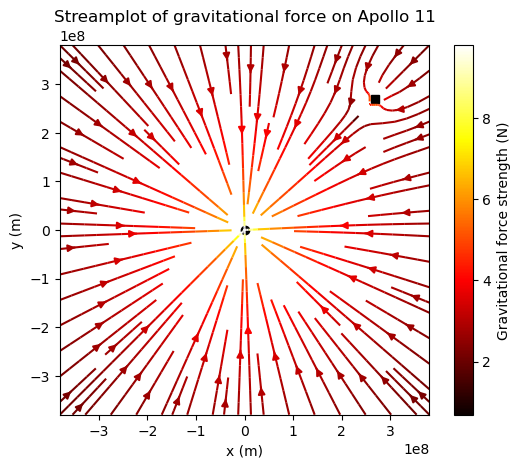

In [9]:
fig,ax=plt.subplots()

ax.plot(0,0,"ko")
ax.plot(dEM/np.sqrt(2),dEM/np.sqrt(2),"ks")
ax.set_aspect("equal")
ax.set_xlim(-dEM,dEM)
ax.set_ylim(-dEM,dEM)

y=np.linspace(-dEM,dEM,50)
x=np.linspace(-dEM,dEM,50)
X,Y=np.meshgrid(x,y)

Fx=np.zeros((50,50))
Fy=np.zeros((50,50))

for y in range(50):
    for x in range(50):
        Fx_e,Fy_e=g_force(Me,Macm,0,0,X[y,x],Y[y,x])

        Fx_m,Fy_m=g_force(Mm,Macm,dEM/np.sqrt(2),dEM/np.sqrt(2),X[y,x],Y[y,x])

        #sum them up
        Fx[y,x] += (Fx_e+Fx_m)
        Fy[y,x] += (Fy_e+Fy_m)

stream=ax.streamplot(X,Y,Fx,Fy,color=np.log(np.hypot(Fx,Fy)),cmap=cm.hot)
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
cbar=fig.colorbar(stream.lines)
cbar.set_label("Gravitational force strength (N)")
ax.set_title("Streamplot of gravitational force on Apollo 11")

3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

Let the force from the Moon be F_m and the force from Earth be F_e.
Let r be the distance from the center of Earth to the balance point and the distance from the balance point to the moon be $d_{EM} - r$. The mass at the balance point of some object is m.
When the magnitude of both forces equals eachother, you get the resulting equation of...

$\frac{G M_e m}{r^2} = \frac{G M_m m}{(d_{EM} - r)^2}$

Now you can cancel out $G$ and $m$.

$\frac{M_e}{r^2} = \frac{M_m}{(d_{EM} - r)^2}$

If we take the sqaure root of both sides we get...


$\frac{\sqrt{M_E}}{r}=\frac{\sqrt{M_M}}{d_{EM} - r}$


Rearrange...


$\sqrt{M_E}(d_{EM} - r)=\sqrt{M_M} r$

Further rearranging gives us this final equation for the radial balance point, r.

$r=\frac{\sqrt{M_E}}{\sqrt{M_E} + \sqrt{M_M}} d_{EM}$


And your updated plot, including the balance point, goes in the cell below.

341962346.91181517
38037653.08818483


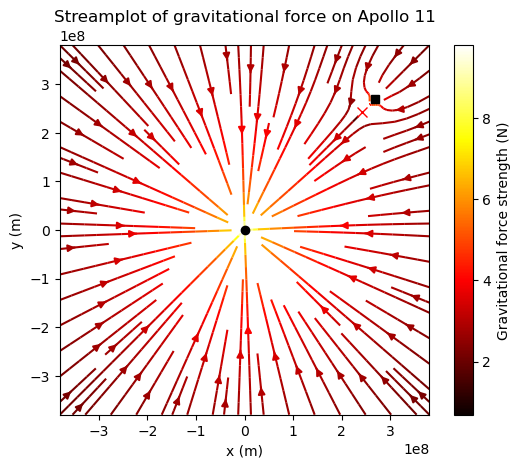

In [10]:
r_balance=(np.sqrt(Me)*dEM)/(np.sqrt(Me)+np.sqrt(Mm))

fig,ax=plt.subplots()
stream=ax.streamplot(X,Y,Fx,Fy,color=np.log(np.hypot(Fx,Fy)),cmap=cm.hot)
ax.plot(0,0,"ko")
ax.plot(dEM/np.sqrt(2),dEM/np.sqrt(2),"ks")
ax.set_aspect("equal")
ax.set_xlim(-dEM,dEM)
ax.set_ylim(-dEM,dEM)

ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
cbar=fig.colorbar(stream.lines)
cbar.set_label("Gravitational force strength (N)")
ax.set_title("Streamplot of gravitational force on Apollo 11")

x_balance=r_balance/np.sqrt(2)
y_balance=x_balance
ax.plot(x_balance,y_balance,"rx",markersize="7")
print(r_balance)
print(dEM-r_balance)


4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

The balance point I got is very close to the moon. It is around 38,000,000 meters away from the Moon while being around 342,000,000 meters away from Earth. This makes sense because the force of gravity relies on the seperation of two objects more than the mass of two objects (the force of gravitation is inversely proportional to $\frac{1}{r^2}$ while being directly proportional to $M*M_{small}$). The 1 over the radius squared term overpowers the mass relation. This explains why the force of gravity from Earth falls off so fast when it gets closer to the moon since the force of gravity greatly decreases with distance.

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [11]:
mdot=burn #fuel burn rate
m0=Mwet #wet mass
mf=Mdry #dry mass

T_burn=(m0-mf)/mdot
print(T_burn)

157.69230769230768


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [12]:
def delta_v(T,m0,mf,mdot,v_e,g):
    """A function which calculates the change in velocity of a rocket over a period of time T

    Args:
        T (int,float): The burn time in seconds
        m0 (int,float): The wet mass in kg
        mf (int,float): The dry mass in kg
        mdot (int,float): The fuel burn rate in kg per second
        v_e (int,float): The exhaust speed in meters per second
        g (int,float): The acceleration due to gravity in meters per second squared

    Returns:
        delta_v (int,float): The change in velocity in meters per second 
    """
    if not all(isinstance(v,(int,float)) for v in (T,m0,mf,mdot,v_e,g)):
        raise TypeError("Inputs of the wrong type")
    elif mdot <=0:
        raise ValueError("Burn rate must be positive")

    T_end=min(T,T_burn) #Check if the time given is smaller or if time is greater than total burn time 
    #Important for cutting off burning of mass after fuel is spent
    
    mt=m0-mdot*T_end

    delta_v=v_e*np.log(m0/mt)-g*T_end

    return delta_v



    

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [13]:
alt,alt_err=integrate.quad(delta_v,0,T_burn,args=(m0,mf,mdot,exh_v,g))
print(alt)
print(alt_err)

74093.98013366401
5.848811185394151e-08


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

My calculations gave me a time of 158 seconds for T (T_burn) and an altitude of 74 kilometers (alt). My time is 2 seconds smaller than the testing results and my altitude is 4 kilometers greater than the testing results. It is likely that my calculation is an overestimate of 4 kilometers because it doesn't account for the drag force of air (friction) exerted on the rocket. This is much harder to mathematically represent without knowing the aerodynamic traits of the rocket or its shape. Additionally, my model assumes a constant acceleration due to gravity (g) when in fact this changes as you move farther away from the surface of the Earth. For the burn time, the number was likely underestimated because for most rocket engines it takes time to reach full thrust and a thruster won't instantaneously use its full capability. This, in turn, means that at different times the rocket had a small fuel burn rate which would account for a larger burn time.